# Churn models — LR, Random Forest, XGBoost

Section 6.4 workflow: **5-fold stratified CV** on the training slice, **Fβ threshold tuning** (β > 1, favor recall) on a held-out **validation** set, final refit on **train+validation** and evaluation on **test**. **Interpretability:** logistic regression coefficients; XGBoost SHAP summary plot.

**Run this notebook with the working directory set to `notebooks/`** (paths use `../data` and `../outputs`).

**macOS:** If `import xgboost` fails with `libomp.dylib` missing, install OpenMP (e.g. `brew install libomp`) and retry.

In [2]:
import warnings

from pathlib import Path

# sklearn can emit matmul overflow warnings during weighted LR; fits are still valid
warnings.filterwarnings(
    'ignore', category=RuntimeWarning, module=r'sklearn\.utils\.extmath',
)
warnings.filterwarnings(
    'ignore', category=RuntimeWarning, module=r'sklearn\.linear_model\._linear_loss',
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    fbeta_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from xgboost import XGBClassifier

In [3]:
RANDOM_STATE = 42
FBETA_BETA = 2.0  # β > 1 weights recall more than precision

DATA_PATH = Path('../data/curated.parquet')
OUT_INTERP = Path('../outputs/interpretability')
OUT_INTERP.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
X = df.drop(columns=['Churn'])
y = df['Churn']
X = X.astype(np.float64)
X = X.replace([np.inf, -np.inf], 0.0).fillna(0.0)
feature_names = list(X.columns)
print(f'Loaded {len(df):,} rows, {X.shape[1]} features. Churn rate: {y.mean():.2%}')


Loaded 7,043 rows, 26 features. Churn rate: 26.54%


## 1. Train / validation / test split

Stratified **80%** holdout for development vs **20%** final test. The 80% is split again **75% / 25%** → **60% train**, **20% validation**, **20% test** overall.

In [4]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)
print(
    'Train:', len(X_train),
    '| Val:', len(X_val),
    '| Test:', len(X_test),
    '| Pos rate train/val/test:',
    f'{y_train.mean():.3f} / {y_val.mean():.3f} / {y_test.mean():.3f}',
)

Train: 4225 | Val: 1409 | Test: 1409 | Pos rate train/val/test: 0.265 / 0.265 / 0.265


## 2. Model factories

- **Logistic Regression** and **Random Forest:** `class_weight='balanced'`.
- **XGBoost:** no `class_weight`; use **`scale_pos_weight = n_negative / n_positive`** on the **training** labels (recomputed when fitting on a subset).

In [5]:
def make_lr():
    return LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=2000,
        solver='liblinear',
        dual=False,
    )


def make_rf():
    return RandomForestClassifier(
        class_weight='balanced',
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def make_xgb(y_tr):
    n_neg = int((y_tr == 0).sum())
    n_pos = int((y_tr == 1).sum())
    spw = n_neg / max(1, n_pos)
    return XGBClassifier(
        scale_pos_weight=spw,
        random_state=RANDOM_STATE,
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        n_jobs=-1,
    )


MODEL_BUILDERS = {
    'LogisticRegression': lambda yt: make_lr(),
    'RandomForest': lambda yt: make_rf(),
    'XGBoost': lambda yt: make_xgb(yt),
}

## 3. Five-fold stratified cross-validation (train set only)

Out-of-fold predicted probabilities → ROC-AUC and **Fβ** at default 0.5 threshold (quick CV signal; operating threshold is chosen on the validation set next).

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def cv_metrics(name, builder):
    probs = np.zeros(len(y_train))
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train)):
        xtr, xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        ytr, yva = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        est = builder(ytr)
        est.fit(xtr, ytr)
        probs[va_idx] = est.predict_proba(xva)[:, 1]
    auc = roc_auc_score(y_train, probs)
    pred05 = (probs >= 0.5).astype(int)
    fb = fbeta_score(y_train, pred05, beta=FBETA_BETA, zero_division=0)
    return auc, fb, probs


cv_rows = []
for name, builder in MODEL_BUILDERS.items():
    auc, fb, _ = cv_metrics(name, builder)
    cv_rows.append({'model': name, 'cv_roc_auc': auc, f'cv_f{FBETA_BETA:g}_at_0.5': fb})
cv_summary = pd.DataFrame(cv_rows)
display(cv_summary)

,model,cv_roc_auc,cv_f2_at_0.5
0,LogisticRegression,0.847384,0.725560
1,RandomForest,0.829917,0.512797
2,XGBoost,0.833195,0.670608


## 4. Threshold tuning — maximize Fβ on the validation set

Fit on **train** only; sweep probability thresholds on **validation** predictions.

In [7]:
def tune_threshold_fbeta(y_true, y_prob, beta=FBETA_BETA, n=201):
    ts = np.linspace(0.0, 1.0, n)
    best_t, best_f = 0.5, -1.0
    for t in ts:
        pred = (y_prob >= t).astype(int)
        f = fbeta_score(y_true, pred, beta=beta, zero_division=0)
        if f > best_f:
            best_f, best_t = f, float(t)
    return best_t, best_f


thresholds = {}
val_fbeta = {}
fitted_train = {}

for name, builder in MODEL_BUILDERS.items():
    est = builder(y_train)
    est.fit(X_train, y_train)
    p_val = est.predict_proba(X_val)[:, 1]
    t_best, f_best = tune_threshold_fbeta(y_val.to_numpy(), p_val)
    thresholds[name] = t_best
    val_fbeta[name] = f_best
    fitted_train[name] = est
    print(f'{name}: best threshold={t_best:.4f}, val F{FBETA_BETA:g}={f_best:.4f}')

LogisticRegression: best threshold=0.3050, val F2=0.7400
RandomForest: best threshold=0.1150, val F2=0.7401
XGBoost: best threshold=0.2300, val F2=0.7399


## 5. Final models — refit on train + validation, evaluate on test

Same hyperparameters; **threshold** fixed from the validation sweep above.

LogisticRegression | threshold=0.3050
              precision    recall  f1-score   support

           0     0.9557    0.5623    0.7080      1035
           1     0.4338    0.9278    0.5911       374

    accuracy                         0.6593      1409
   macro avg     0.6947    0.7451    0.6496      1409
weighted avg     0.8171    0.6593    0.6770      1409



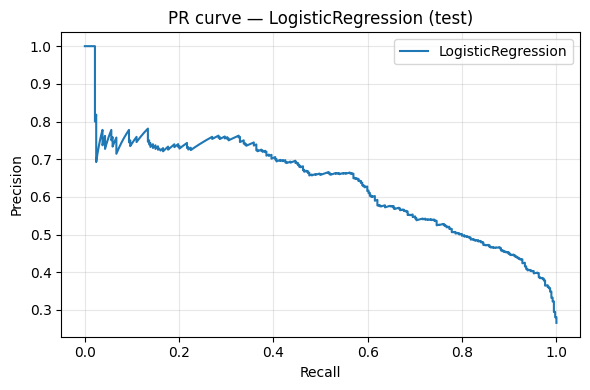

RandomForest | threshold=0.1150
              precision    recall  f1-score   support

           0     0.9348    0.5266    0.6737      1035
           1     0.4068    0.8984    0.5600       374

    accuracy                         0.6253      1409
   macro avg     0.6708    0.7125    0.6168      1409
weighted avg     0.7947    0.6253    0.6435      1409



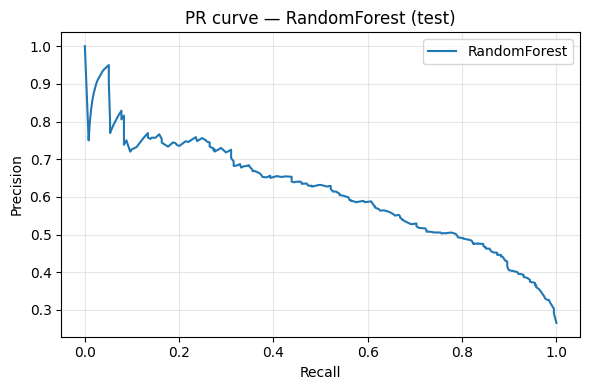

XGBoost | threshold=0.2300
              precision    recall  f1-score   support

           0     0.9299    0.5894    0.7215      1035
           1     0.4356    0.8770    0.5821       374

    accuracy                         0.6657      1409
   macro avg     0.6827    0.7332    0.6518      1409
weighted avg     0.7987    0.6657    0.6845      1409



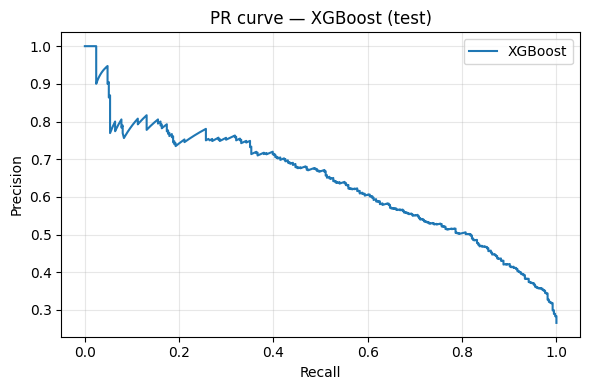

In [8]:
X_tv = pd.concat([X_train, X_val], axis=0)
y_tv = pd.concat([y_train, y_val], axis=0)

final_models = {}
test_reports = {}

for name, builder in MODEL_BUILDERS.items():
    est = builder(y_tv)
    est.fit(X_tv, y_tv)
    final_models[name] = est
    p_test = est.predict_proba(X_test)[:, 1]
    t = thresholds[name]
    y_hat = (p_test >= t).astype(int)
    print('=' * 60)
    print(name, f'| threshold={t:.4f}')
    print(classification_report(y_test, y_hat, digits=4))
    test_reports[name] = classification_report(y_test, y_hat, digits=4)

    prec, rec, _ = precision_recall_curve(y_test, p_test)
    plt.figure(figsize=(6, 4))
    plt.plot(rec, prec, label=name)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR curve — {name} (test)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. Interpretability — Logistic Regression coefficients

Coefficients are on the **scaled** numeric features from the ETL pipeline; one-hot columns are 0/1.

In [9]:
lr_final = final_models['LogisticRegression']
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr_final.coef_.ravel(),
    'odds_ratio': np.exp(lr_final.coef_.ravel()),
}).sort_values('coefficient', key=lambda s: s.abs(), ascending=False)

coef_path = OUT_INTERP / 'lr_coefficients.csv'
coef_df.to_csv(coef_path, index=False)
print(f'Saved → {coef_path}')
display(coef_df.head(20))

Saved → ../outputs/interpretability/lr_coefficients.csv


,feature,coefficient,odds_ratio
18,InternetService_No,-1.234475,0.290988
4,tenure,-1.155299,0.314963
21,Contract_Two_year,-0.885183,0.412639
17,InternetService_Fiber_optic,0.876153,2.401643
19,Contract_Month_to_month,0.549236,1.731929
15,TotalCharges,0.487154,1.627677
7,OnlineSecurity,-0.368951,0.691460
12,StreamingMovies,0.349102,1.417793
13,PaperlessBilling,0.336961,1.400684
11,StreamingTV,0.323113,1.381421


## 7. Interpretability — XGBoost SHAP (TreeExplainer)

Summary plot on a **sample** of the test set for speed and readability.

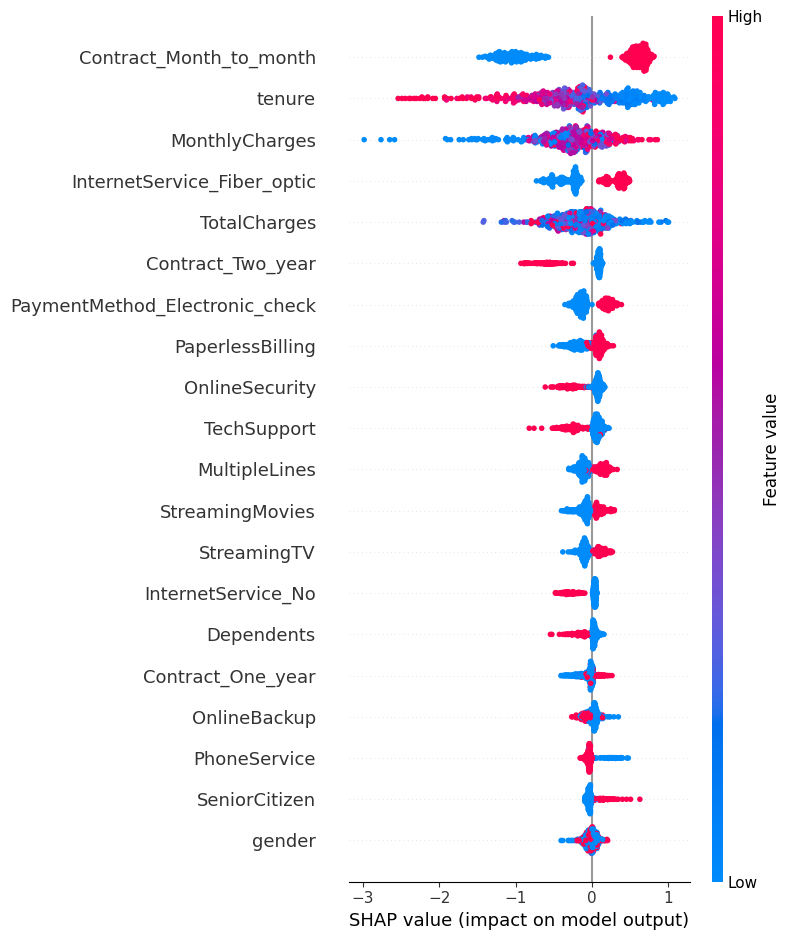

Saved → ../outputs/interpretability/xgb_shap_summary.png


In [10]:
xgb_final = final_models['XGBoost']
rng = np.random.default_rng(RANDOM_STATE)
n_sample = min(500, len(X_test))
idx = rng.choice(len(X_test), size=n_sample, replace=False)
X_shap = X_test.iloc[idx]

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
plt.tight_layout()
shap_path = OUT_INTERP / 'xgb_shap_summary.png'
plt.savefig(shap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {shap_path}')